# Example Notebook: Agar Pad Image Processing

This is an example notebook to specify proper usage of the core image processing notebook used in our agar pad image<br>
processing pipeline. This pipline is ideal for agar pad image data where cells must be segmented in phase contrast.

The steps in this pipeline are as follows:
1. Extracting your Agar Pad data (multiple .nd2 files) into hdf5 format
2. Segmenting cells in phase contrast (using omnipose)
3. Segmenting stained cell nucleoids
4. Measuring segment properties and assigning nucleoid segments to cells

Example data to run this notebook are provided in the associated Zonodo repository `doi:10.5281/zenodo.14537796` at `\path\to\zenodo\Data\Example_Raw_Data\Agar_Pad`

#### Imports

Run this section to import all relavent packages and libraries used in this notebook. You must run this everytime you open a new python kernel.

In [1]:
import trenchripper as tr

import tifffile
import dask
import h5py
import os

import skimage as sk
import pandas as pd
import numpy as np
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import fire_and_forget

from parse import compile
from nd2reader import ND2Reader
from distributed.client import futures_of
from time import sleep

import omnipose
from cellpose_omni import models, core
from omnipose.utils import normalize99

from matplotlib import pyplot as plt

dask.config.set({'distributed.scheduler.active-memory-manager.start': True});
dask.config.set({'distributed.scheduler.worker-ttl': "5m"});
dask.config.set({'distributed.scheduler.allowed-failures': 100});

/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/omnipose/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Load Functions For Notebook

In [2]:
def nd2_to_tiff(nd2file,fov_metadata_chunk,channels,tiff_metadata):
    #### start reading nd2 files
    with ND2Reader(nd2file) as nd2_input:
        for i,channel in enumerate(channels):
            for fov in fov_metadata_chunk.index.get_level_values(0).unique():
                for j in fov_metadata_chunk.index.get_level_values(1).unique():
                    fov_row = fov_metadata_chunk.loc[fov,j]
                    output_filename = fov_row[channel + " File Names"]
                    output_filename_path = tiff_output_path + "/" + output_filename
                    fovnum = fov_row["old fov"]
                    nd2_image = nd2_input.get_frame_2D(c=i, t=j, v=fovnum)
                    nd2_image = np.array(nd2_image)
                    tifffile.imwrite(output_filename_path,data=nd2_image,dtype="uint16",\
                                    extratags=tiff_metadata)
    return 1

def segment_omnipose(headpath,img_idx,seg_channel,min_size=500,border_buffer=4):
    imgpath = headpath + "/hdf5/hdf5_" + str(img_idx) + ".hdf5"
    segpath = headpath + "/phasesegmentation/segmentation_" + str(img_idx) + ".hdf5"
    with h5py.File(imgpath,"r") as infile:
        img_data = infile[seg_channel][:]

    try:
        img_data = normalize99(img_data)
        use_GPU = core.use_gpu()
        model_name = 'bact_phase_omni'
        model = models.CellposeModel(gpu=use_GPU, model_type=model_name)
        omni_masks, _, _ = model.eval(img_data,channels=[0,0],rescale=None,mask_threshold=-1,
                transparency=True,flow_threshold=0,
                niter=None,omni=True,cluster=True,resample=True,
                verbose=False,affinity_seg=0,tile=True,
                augment=False)

        omni_masks = omni_masks[0]
        unlabeled_composite_mask = omni_masks>0
        unlabeled_composite_mask = ~sk.morphology.binary_closing(~unlabeled_composite_mask)
        omni_masks[~unlabeled_composite_mask] = 0
        
        omni_masks = sk.morphology.remove_small_objects(omni_masks,min_size=min_size)
        omni_masks = sk.segmentation.clear_border(omni_masks,buffer_size=border_buffer)
        omni_masks,_,_ = sk.segmentation.relabel_sequential(omni_masks)
        omni_masks = omni_masks[np.newaxis,np.newaxis,:,:] #compatability with the mother machine code (k,t,y,x)
    except:
        omni_masks = np.zeros((1,1,img_data.shape[1],img_data.shape[2]),dtype="uint8")
        
    with h5py.File(segpath,"w") as outfile:
        outfile["data"] = omni_masks
    return 1

def segment_nucleoids(file_idx,headpath,cellsegfolder,nucleoidsegfolder,seg_channel,cell_otsu_scaling,\
                      min_size=400,border_buffer=4):
    with h5py.File(headpath + '/hdf5/hdf5_' + str(file_idx) + '.hdf5',"r") as infile:
        img_data = infile[seg_channel][:]
    with h5py.File(headpath + "/" + cellsegfolder + "/segmentation_" + str(file_idx) + ".hdf5","r") as infile:
        seg_data = infile["data"][:]

    img_arr = img_data[0]
    seg_arr = seg_data[0,0]

    composite_mask_list = []
    nucleoid_idx = 0
    if np.max(seg_arr)>0:
        for cell_i in range(1,np.max(seg_arr)+1):
            cell_seg_mask = (seg_arr==cell_i)
            cell_otsu_thr = sk.filters.threshold_otsu(img_arr[cell_seg_mask])*cell_otsu_scaling
            composite_mask = cell_seg_mask&(img_arr>cell_otsu_thr)

            composite_mask = sk.morphology.label(composite_mask).astype("uint8")
            nucleoid_idx_increment = np.max(composite_mask)
            composite_mask[composite_mask>0] = composite_mask[composite_mask>0]+nucleoid_idx
            nucleoid_idx += nucleoid_idx_increment
            composite_mask_list.append(composite_mask)
        composite_mask = np.sum(np.stack(composite_mask_list,dtype="uint8"),axis=0,dtype="uint8")
        ##morphological operations
        unlabeled_composite_mask = composite_mask>0
        unlabeled_composite_mask = ~sk.morphology.binary_closing(~unlabeled_composite_mask)
        composite_mask[~unlabeled_composite_mask] = 0
        composite_mask = sk.morphology.remove_small_objects(composite_mask,min_size=min_size)
        composite_mask = sk.segmentation.clear_border(composite_mask,buffer_size=border_buffer)
        composite_mask,_,_ = sk.segmentation.relabel_sequential(composite_mask)

        composite_mask = composite_mask[np.newaxis,np.newaxis,:,:]
        
    else:
        composite_mask = np.zeros((1,1,img_data.shape[1],img_data.shape[2]),dtype="uint8")

    with h5py.File(headpath + "/" + nucleoidsegfolder + "/segmentation_" + str(file_idx) + ".hdf5","w") as outfile:
        outfile["data"] = composite_mask

    return 1

class regionprops_extractor_agarpad:
    # hacky analyzer for analyzing agarpad data
    def __init__(self,headpath,segmentationdir,analysisdir,intensity_channel_list=None,props_list=['centroid','area'],custom_props_list=[],\
                 intensity_props_list=['mean_intensity'],custom_intensity_props_list=[],props_to_unpack={'centroid':["centroid_y","centroid_x"]},\
                 pixel_scaling_factors={'area':2,'centroid_y': 1,'centroid_x': 1}):
        self.headpath = headpath
        self.intensity_channel_list = intensity_channel_list
        self.intensity_channel_dict = {channel:i for i,channel in enumerate(intensity_channel_list)}
        self.hdf5path = headpath + "/hdf5"
        self.segmentationpath = headpath + "/" + segmentationdir

        self.global_metapath = self.headpath + "/metadata.hdf5"
        self.meta_handle = tr.pandas_hdf5_handler(self.global_metapath)
        fovdf = self.meta_handle.read_df("global",read_metadata=True)
        self.metadata = fovdf.metadata

        self.analysispath = headpath + "/" + analysisdir
        self.props_list = props_list
        self.custom_props_list = custom_props_list
        self.custom_props_str_list = [item.__name__ for item in self.custom_props_list]
        self.intensity_props_list = intensity_props_list
        self.custom_intensity_props_list = custom_intensity_props_list
        self.custom_intensity_props_str_list = [item.__name__ for item in self.custom_intensity_props_list]
        self.props_to_unpack = props_to_unpack
        self.pixel_scaling_factors = pixel_scaling_factors

    def get_file_regionprops(self,file_idx):
        pixel_microns = self.metadata['pixel_microns']

        segmentation_file = self.segmentationpath + "/segmentation_" + str(file_idx) + ".hdf5"
        hdf5_file = self.hdf5path + "/hdf5_" + str(file_idx) + ".hdf5"

        with h5py.File(segmentation_file,"r") as segfile:
            seg_arr = segfile["data"][:]
        if self.intensity_channel_list is not None:
            img_arr_list = []
            with h5py.File(hdf5_file,"r") as hdf5file:
                for intensity_channel in self.intensity_channel_list:
                    img_arr_list.append(hdf5file[intensity_channel][:])
        props_output = []
        for t in range(seg_arr.shape[1]):
            labels = sk.measure.label(seg_arr[0,t])
            ## Measure regionprops of background pixels; will always be marked as the first object
            labels += 1

            #non intensity info first
            non_intensity_rps = sk.measure.regionprops(labels,extra_properties=self.custom_props_list)

            if self.intensity_channel_list is not None:
                intensity_rps_list = []
                for i,intensity_channel in enumerate(self.intensity_channel_list):
                    intensity_rps = sk.measure.regionprops(labels, img_arr_list[i][t],extra_properties=self.custom_intensity_props_list)
                    intensity_rps_list.append(intensity_rps)

            for idx in range(len(non_intensity_rps)):
                rp = non_intensity_rps[idx]
                props_entry = [file_idx, t, idx]
                for prop_key in (self.props_list+self.custom_props_str_list):
                    prop = getattr(rp, prop_key)
                    if prop_key in self.props_to_unpack.keys():
                        prop_out = dict(zip(self.props_to_unpack[prop_key],list(prop)))
                    else:
                        prop_out = {prop_key:prop}
                    for key,value in prop_out.items():
                        if key in self.pixel_scaling_factors.keys():
                            output = value*(pixel_microns**self.pixel_scaling_factors[key])
                        else:
                            output = value
                        props_entry.append(output)

                if self.intensity_channel_list is not None:
                    for i,intensity_channel in enumerate(self.intensity_channel_list):
                        intensity_rps=intensity_rps_list[i]
                        inten_rp = intensity_rps[idx]
                        for prop_key in (self.intensity_props_list+self.custom_intensity_props_str_list):
                            prop = getattr(inten_rp, prop_key)
                            if prop_key in self.props_to_unpack.keys():
                                prop_out = dict(zip(self.props_to_unpack[prop_key],list(prop)))
                            else:
                                prop_out = {prop_key:prop}
                            for key,value in prop_out.items():
                                if key in self.pixel_scaling_factors.keys():
                                    output = value*(pixel_microns**self.pixel_scaling_factors[key])
                                else:
                                    output = value
                                props_entry.append(output)

                props_output.append(props_entry)

        base_list = ['File Index','timepoints','Objectid']

        unpacked_props_list = []
        for prop_key in (self.props_list+self.custom_props_str_list):
            if prop_key in self.props_to_unpack.keys():
                unpacked_names = self.props_to_unpack[prop_key]
                unpacked_props_list += unpacked_names
            else:
                unpacked_props_list.append(prop_key)

        if self.intensity_channel_list is not None:
            for channel in self.intensity_channel_list:
                for prop_key in (self.intensity_props_list+self.custom_intensity_props_str_list):
                    if prop_key in self.props_to_unpack.keys():
                        unpacked_names = self.props_to_unpack[prop_key]
                        unpacked_props_list += [channel + " " + item for item in unpacked_names]
                    else:
                        unpacked_props_list.append(channel + " " + prop_key)

        column_list = base_list + unpacked_props_list

        df_out = pd.DataFrame(props_output, columns=column_list).reset_index()
        file_idx = df_out.apply(lambda x: int(f'{x["File Index"]:08n}{x["timepoints"]:04n}{x["Objectid"]:02n}'), axis=1)

        df_out["File Parquet Index"] = [item for item in file_idx]
        df_out = df_out.set_index("File Parquet Index").sort_index()
        del df_out["index"]

        return df_out

    def analyze_all_files(self,dask_cont):
        fovdf = self.meta_handle.read_df("global",read_metadata=True)
        file_list = fovdf["File Index"].unique().tolist()

        delayed_list = []
        for file_idx in file_list:
            df_delayed = delayed(self.get_file_regionprops)(file_idx)
            delayed_list.append(df_delayed.persist())

        ## filtering out non-failed dataframes ##
        all_delayed_futures = []
        for item in delayed_list:
            all_delayed_futures += futures_of(item)
        while any(future.status == "pending" for future in all_delayed_futures):
            sleep(0.1)

        good_delayed = []
        for item in delayed_list:
            if all([future.status == "finished" for future in futures_of(item)]):
                good_delayed.append(item)

        ## compiling output dataframe ##
        df_out = dd.from_delayed(good_delayed).persist()
        df_out["File Parquet Index"] = df_out.index
        df_out = df_out.set_index("File Parquet Index", drop=True, sorted=False)
        df_out = df_out.repartition(partition_size="25MB").persist()

        fovdf = fovdf.reset_index()
        fovdf["File Merge Index"] = fovdf.apply(lambda x: int(f'{x["File Index"]:08n}{x["timepoints"]:04n}'), axis=1)
        fovdf = fovdf.set_index("File Merge Index")
        fovdf = fovdf.drop(["File Index","timepoints"], axis=1)

        df_out["File Merge Index"] = df_out.apply(lambda x: int(f'{x["File Index"]:08n}{x["timepoints"]:04n}'), axis=1)
        df_out = df_out.reset_index(drop=True)
        df_out = df_out.set_index("File Merge Index", sorted=True)

        df_out = df_out.join(fovdf)
        df_out = df_out.set_index("File Parquet Index",sorted=True)

        dd.to_parquet(
            df_out,
            self.analysispath,
            engine="pyarrow",
            compression="gzip",
            write_metadata_file=True,
        )

def nucleoid_cellid(headpath,nuc_df_block,pixel_microns):
    nuc_df_block = nuc_df_block.sort_index()
    idx = nuc_df_block.iloc[0]["File Index"]
    with h5py.File(headpath + "/nucleoidsegmentation/segmentation_" + str(idx) + ".hdf5","r") as infile:
        data = (infile['data'][0,0])
    nucleoid_coords = nuc_df_block[["centroid_y","centroid_x"]].apply(lambda x: (int(np.round(x["centroid_y"]/pixel_microns)),int(np.round(x["centroid_x"]/pixel_microns))), axis=1)
    assgined_cell = nucleoid_coords.apply(lambda x: data[x])
    nuc_df_block["Cell Objectid"] = assgined_cell
    return nuc_df_block

## Set Path to Data Folder

- Also set `analysis_is_local` to `True` if working on a single machine or `False` if working on a `SLURM` cluster.
- If using a `SLURM` cluster, set `dask_workingdir` to your scratch path.

In [3]:
path_to_data = "./"
path_to_example_data = path_to_data + "Example_Raw_Data/Agar_Pad"
analysis_is_local = True
dask_workingdir = "./dask"

# Flat Field Generation

If you have not done so, generate reference images, derived from imaging a uniform fluorescent sample (usually<br>
a dye solution spread on a coverslip). Use the following code to generate such composite images for use in the<br>
pipeline from sample images in ```.nd2``` format.

### Dark Image

In [81]:
flatfieldpath = path_to_example_data + "/40x_DarkImage.nd2"
outputpath = path_to_example_data + "/40x_DarkImage.tiff"
tr.generate_flatfield(flatfieldpath,outputpath)

### BFP

In [82]:
flatfieldpath = path_to_example_data + "/BFP-Penta.nd2"
outputpath = path_to_example_data + "/BFP-Penta.tiff"
tr.generate_flatfield(flatfieldpath,outputpath)

### GFP

In [83]:
flatfieldpath = path_to_example_data + "/GFP-Penta.nd2"
outputpath = path_to_example_data + "/GFP-Penta.tiff"
tr.generate_flatfield(flatfieldpath,outputpath)

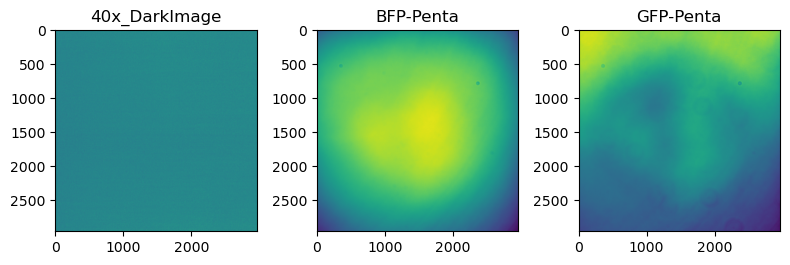

In [85]:
dark_outputpath = path_to_example_data + "/40x_DarkImage.tiff"
bfp_outputpath = path_to_example_data + "/BFP-Penta.tiff"
gfp_outputpath = path_to_example_data + "/GFP-Penta.tiff"

fflist = [dark_outputpath,bfp_outputpath,gfp_outputpath]

fig, axs = plt.subplots(figsize=(8, 12), nrows= 1, ncols = 3)

for i in range(3):
    axs[i].imshow(tifffile.imread(fflist[i]))
    axs[i].set_title(fflist[i].split('/')[-1].split(".")[0])
plt.tight_layout()

# Segmentation and Analysis

#### Specify Paths

Begin by defining the directory in which all processing will be done, as well as the initial nd2 file we will be <br>processing. This line should be run everytime you open a new python kernel.

The format should be: `nd2path = "/path/to/nd2folder"` and `tiff_output_path = "/path/to/tifffolder"`

For example:
```
headpath = "/n/scratch2/de64/2019-05-31_validation_data"
nd2file = "/n/scratch2/de64/2019-05-31_validation_data/tiff"
```

Ideally, these files should be placed in a storage location with relatively fast read and write speed.

In [14]:
nd2path = path_to_example_data
tiff_output_path = path_to_example_data + "/tiff"

## Extracting Files

This section converts the raw acquisition files into the on-disk format that TrenchRipper expects for the rest of the pipeline. In this notebook, the raw data are **multiple `.nd2` files** (e.g. `DE{Strain}_R{Run}.nd2`) and we standardize them into:

1. **A per-frame TIFF cache** (optional but recommended): one TIFF per *(timepoint, FOV, channel)* with a consistent filename pattern.
2. **HDF5 “chunks” for analysis**: written to `path_to_example_data/hdf5/` as `hdf5_{File Index}.hdf5`, where each file contains a time-stack for each channel.
3. **A metadata table**: written to `path_to_example_data/metadata.hdf5` (the `"global"` dataframe) that maps each image to its `File Index`, `Image Index`, `fov`, `timepoints`, and other annotations used downstream.
ream.
ream.


#### Start Dask Workers

First, we start a `dask_controller` instance which will handle all of our parallel processing. The default parameters <br>here work well on O2. The critical arguments here are:

**walltime** : For a cluster, the length of time you will request each node for.

**local** : `True` if you want to perform computation locally. `False` if you want to perform it on a SLURM cluster.

**n_workers** : Maximum number of nodes to request, will request if computation is triggered requiring many nodes.

**n_workers_min** : Number of nodes to immediately request.

**memory** : For a cluster, the amount of memory you will request each node for.

**working_directory** : For a cluster, the directory in which data will be spilled to disk. Usually set as a folder in <br>the `path_to_example_data`.

In [25]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

50m
1:00:00


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41259 instead
  warnings.warn(


#### Link to the Dask Dashboard

In [26]:
if analysis_is_local is False:
    dask_controller.displaydashboard()

### ND2 → TIFF

- **ND2 discovery / parsing (`parsestr`)**: the notebook searches `nd2path` for files matching:
  - `parsestr = "DE{Strain:d}_R{Run:d}.nd2"`
  - The parsed fields (e.g. `Strain`, `Run`) are appended to the per-FOV metadata so you can trace every extracted image back to its source file and condition.

- **Output TIFF filenames**: TIFFs are written into `tiff_output_path` using the pattern:
  - `t{timepoints:d}xy{fov:d}c{channel:d}.tif`
  - Here, `fov` is a **global FOV index** across *all* ND2 files (so FOV IDs don’t collide between `DE*_R*.nd2` files). The original within-ND2 index is preserved in the metadata as `"old fov"`.

- **Conversion bookkeeping**: after conversion, the notebook saves a table at:
  - `tiff_output_path + "/conversion_metadata.pkl"`
  - This is useful for checking which global FOVs correspond to each `(Strain, Run)` and for validating that all expected files were found.


In [27]:
# convert nd2 files to tiff (custom) of format t{timepoints:d}xy{fov:d}c{channel:d}.tif
# record mapping from condition to fov range in secondary dataframe

parsestr = "DE{Strain:d}_R{Run:d}.nd2"

parser = compile(parsestr)
tr.writedir(tiff_output_path, overwrite=True)

nd2_files = []
for root, _, files in os.walk(nd2path):
    for f in files:
        match = parser.search(f)
        if match is not None:
            nd2_files.extend([os.path.join(root, f)])

ndmeta_handle = tr.nd_metadata_handler(nd2_files[0],ignore_fovmetadata=False)
exp_metadata,fov_metadata = ndmeta_handle.get_metadata()
tiff_metadata = [(65326,'d',1,exp_metadata['pixel_microns'],True)]
channels = exp_metadata["channels"]

running_fov_idx = 0

all_fov_metadata = []
dask_futures = {}
for nd2_i,nd2_file in enumerate(nd2_files):
    
    ndmeta_handle = tr.nd_metadata_handler(nd2_file,ignore_fovmetadata=False)
    exp_metadata,fov_metadata = ndmeta_handle.get_metadata()
    new_fov_series = fov_metadata.reset_index()["fov"] + running_fov_idx
    fov_metadata = fov_metadata.reset_index()
    fov_metadata = fov_metadata.rename(columns={"fov": "old fov"})
    fov_metadata["fov"] = new_fov_series
    fov_metadata = fov_metadata.set_index(["fov","timepoints"])
    
    for i,channel in enumerate(exp_metadata['channels']):
        file_name_series = fov_metadata.reset_index().apply(lambda x: "t" + str(int(x["timepoints"])) + "xy" + str(int(x["fov"])) + "c" + str(i) + ".tif", axis=1)
        file_name_series.index = fov_metadata.index
        fov_metadata[channel + " File Names"] = file_name_series

    match = parser.search(nd2_file)
    # Add to dictionary
    parser_dict = match.named
    for key, value in parser_dict.items():
        fov_metadata[key] = value

    all_fov_metadata.append(fov_metadata)
    running_fov_idx += len(fov_metadata)
    
    dask_controller.futures["nd2 Convert: " + str(nd2_i)] = dask_controller.daskclient.submit(nd2_to_tiff,nd2_file,fov_metadata,channels,tiff_metadata)
all_fov_metadata = pd.concat(all_fov_metadata)
dask_controller.daskclient.gather([future for key,future in dask_controller.futures.items() if "nd2 Convert" in key]);
all_fov_metadata.to_pickle(tiff_output_path + "/conversion_metadata.pkl")

### TIFF → HDF5 extraction

After TIFF conversion, we use `tiff_extractor` to build the HDF5 archives and the experiment metadata.

The two interactive configuration calls expose the parameters you’ll most commonly adjust:

- `tiff_extractor.inter_set_params()`
  - **fov_list**: choose which FOVs to include (useful for testing on a small subset).
  - **t_range**: choose a timepoint window to extract (also useful for fast testing).
  - **organism**, **microscope**, **notes**: optional text annotations that get stored in the experiment metadata.

- `tiff_extractor.inter_set_flatfieldpaths()`
  - For each channel, provide a path for **`<channel> Flatfield Path`** if you want flatfield correction during extraction.
  - Also provide **`Dark_Image`** if you have one (used for dark-current/background correction).
  - Leaving paths blank skips correction for that channel.

Finally, `tiff_extractor.extract(dask_controller)` performs the extraction and writes:
- `path_to_example_data/hdf5/hdf5_{File Index}.hdf5`
- `path_to_example_data/metadata.hdf5`

In [35]:
channels = ["GFP-Penta","BFP-Penta","MicroManager-Phase"]
tiff_extractor = tr.tiff_extractor(tiff_output_path,nd2path,channels)

In [36]:
tiff_extractor.inter_set_params()

/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is a Python keyword: 'global'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/de64/TrenchRipper/trenchripper/utils.py:86: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['channel_paths'], dtype='object')]

  store.put(key, df)
/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


interactive(children=(SelectMultiple(description='fov_list', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12…

In [43]:
tiff_extractor.inter_set_flatfieldpaths()

In [44]:
tiff_extractor.extract(dask_controller)

/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is a Python keyword: 'global'; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/de64/TrenchRipper/trenchripper/utils.py:86: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['channel_paths'], dtype='object')]

  store.put(key, df)
/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is a Python keyword: 'global'; you will not

In [27]:
dask_controller.shutdown()

Done.


### Phase Segmentation (Omnipose)

This step segments **cells in phase contrast** using Omnipose (a Cellpose-based model) and writes instance masks that are used by all downstream measurements. **A CUDA-capable Ged*will greatly accelerate this steps).

For each `File Index` in `metadata.hdf5`, we load the phase image stack from `hdf5/hdf5_{File Index}.hdf5` (channel set by `seg_channel`, e.g. `"MicroManager-Phase"`) and save masks to:

- `phasesegmentation/segmentation_{File Index}.hdf5` (dataset `"data"`; stored as `(k,t,y,x)` for compati with TrenchRipperbility)

Basic post-processing removes tiny objects (`min_size`) and clears objects near the image border (`border_buffer`).


In [39]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

50m
1:00:00


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39773 instead
  warnings.warn(
2026-01-05 16:17:52,409 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle dbc0b589da7e8de8f65c1d8057ad660b initialized by task ('shuffle-transfer-dbc0b589da7e8de8f65c1d8057ad660b', 12) executed on worker tcp://127.0.0.1:42551
2026-01-05 16:17:53,875 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle dbc0b589da7e8de8f65c1d8057ad660b deactivated due to stimulus 'task-finished-1767647873.8736155'


#### Link to the Dask Dashboard

In [40]:
if analysis_is_local is False:
    dask_controller.displaydashboard()

#### Segment Here

In [45]:
seg_channel = "MicroManager-Phase"
overwrite = True #current run was false

tr.writedir(path_to_example_data + "/phasesegmentation", overwrite=overwrite)
meta_handle = tr.pandas_hdf5_handler(path_to_example_data + "/metadata.hdf5")
file_idx_list = np.unique(meta_handle.read_df("global")["File Index"])

for file_idx in file_idx_list:
    dask_controller.futures["Omnipose: " + str(file_idx)] = dask_controller.daskclient.submit(segment_omnipose,path_to_example_data,file_idx,seg_channel)
    fire_and_forget(dask_controller.futures["Omnipose: " + str(file_idx)])
dask_controller.daskclient.gather([future for key,future in dask_controller.futures.items() if "Omnipose" in key]);

2026-01-05 16:16:31,707 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:16:31,708 [INFO] >>bact_phase_omni<< model set to be used
2026-01-05 16:16:31,712 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:16:31,712 [INFO] >>>> using GPU


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/cellpose_omni/resnet_torch.py:295: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.l

2026-01-05 16:16:38,882 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:16:38,883 [INFO] >>bact_phase_omni<< model set to be used
2026-01-05 16:16:38,886 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:16:38,886 [INFO] >>>> using GPU


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/cellpose_omni/resnet_torch.py:295: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.l

2026-01-05 16:16:46,705 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:16:46,706 [INFO] >>bact_phase_omni<< model set to be used
2026-01-05 16:16:46,708 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:16:46,708 [INFO] >>>> using GPU


...

/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/cellpose_omni/resnet_torch.py:295: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.l

2026-01-05 16:17:14,443 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:17:14,443 [INFO] >>bact_phase_omni<< model set to be used
2026-01-05 16:17:14,445 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:17:14,445 [INFO] >>>> using GPU


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/cellpose_omni/resnet_torch.py:295: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.l

2026-01-05 16:17:18,588 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:17:18,590 [INFO] >>bact_phase_omni<< model set to be used
2026-01-05 16:17:18,592 [INFO] ** TORCH GPU version installed and working. **
2026-01-05 16:17:18,592 [INFO] >>>> using GPU


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/cellpose_omni/resnet_torch.py:295: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.l

In [ ]:
dask_controller.shutdown()

### Nucleoid Segmentation (Cell-wise Otsu)

This step segments **nucleoids within each previously-segmented cell** using a simple, robust rule: for every cell mask from `phasesegmentation/segmentation_{File Index}.hdf5`, we compute an **Otsu threshold on the nucleoid fluorescence channel** (`nuc_seg_channel`, e.g. `"BFP-Penta"`) *restricted to that cell’s pixels*, then threshold the image inside the cell to get a nucleoid mask.

- `cell_otsu_scaling` scales the per-cell Otsu threshold (values >1 make the segmentation more stringent; <1 more permissive).
- Small objects are removed with `min_size`, and border-touching objects are cleared with `border_buffer`.

Masks are written to:

- `nucleoidsegmentation/segmentation_{File Index}.hdf5` (dataset `"data"`, stored as `(1,1,y,x)`)

This runs in parallel by submitting `segment_nucleoids(...)` jobs to the `dask_controller`.
ntroller`.


In [12]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

50m
1:00:00


/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36289 instead
  warnings.warn(
2026-01-05 13:07:23,296 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 592cd7ba46cf4a1889b7e978c765a554 initialized by task ('shuffle-transfer-592cd7ba46cf4a1889b7e978c765a554', 13) executed on worker tcp://127.0.0.1:44851
2026-01-05 13:07:25,446 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 592cd7ba46cf4a1889b7e978c765a554 deactivated due to stimulus 'task-finished-1767636445.443826'
2026-01-05 13:18:32,583 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44117' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'segment_nucleoids-e1cf27bebd1dc19242a7627d43e633aa', 'segment_nucleoids-8ece7f36ffb4d2f451eff4ae5b56b078', 'segment_nucleoids-a03210aaff0ab05b70d2989340ce88

#### Link to the Dask Dashboard

In [13]:
if analysis_is_local is False:
    dask_controller.displaydashboard()

In [46]:
cell_otsu_scaling = 1.
nuc_seg_channel = "BFP-Penta"
nucleoidsegfolder = "nucleoidsegmentation"
cellsegfolder = "phasesegmentation"

overwrite = True

tr.writedir(path_to_example_data + "/" + nucleoidsegfolder, overwrite=overwrite)
meta_handle = tr.pandas_hdf5_handler(path_to_example_data + "/metadata.hdf5")
file_idx_list = np.unique(meta_handle.read_df("global")["File Index"])

for file_idx in file_idx_list:
    dask_controller.futures["Nucleoid: " + str(file_idx)] = dask_controller.daskclient.submit(segment_nucleoids,file_idx,path_to_example_data,cellsegfolder,nucleoidsegfolder,nuc_seg_channel,cell_otsu_scaling)
    fire_and_forget(dask_controller.futures["Nucleoid: " + str(file_idx)])
dask_controller.daskclient.gather([future for key,future in dask_controller.futures.items() if "Nucleoid" in key]);

/tmp/ipykernel_2103412/1654246358.py:108: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
/tmp/ipykernel_2103412/1654246358.py:108: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
/tmp/ipykernel_2103412/1654246358.py:110: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/tmp/ipykernel_2103412/1654246358.py:110: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the paramet

### Regionprops Parallelizer

This step computes per-object measurements (geometry + fluorescence intensity) from the saved segmentation masks, and writes the results as a **columnar parquet dataset** for fast downstream plotting/analysis.

For each `File Index`, the analyzer:
- Loads the label mask from `/<segmentationdir>/segmentation_{File Index}.hdf5` (dataset `"data"`)
- Optionally loads one or more intensity channels from `/hdf5/hdf5_{File Index}.hdf5`
- Runs `skimage.measure.regionprops(...)` per timepoint to extract features for every labeled object

The computation is parallelized across files using the active `dask_controller` via `analyze_all_files(dask_controller)`.

**Key parameters (in the constructor call below):**
- `intensity_channel_list`: which fluorescence channels to summarize per object (e.g. mean intensity).
- `props_list`: which geometric properties to extract (e.g. `"centroid"`, `"area"`, `"major_axis_length"`).
- `pixel_scaling_factors`: converts pixel-based outputs into physical units using `pixel_microns` from `metadata.hdf5`
  - e.g. `area: 2` applies a `pixel_microns**2` scaling, while lengths typically use `1`.
  - `"centroid"` is unpacked into `"centroid_y"` and `"centroid_x"` before scaling.

**Outputs:**
- A parquet “folder” written to `/<analysisdir>/` (e.g. `cell_analysis/` or `nuc_analysis/`), compressed with gzip.
  This contains one row per *(File Index, timepoint, object)* with the requested properties and intensity summaries.
ntensity summaries.


In [56]:
cell_analyzer = regionprops_extractor_agarpad(
    path_to_example_data,
    "phasesegmentation",
    "cell_analysis",
    intensity_channel_list=['BFP-Penta','GFP-Penta'],
    props_list=["centroid","area","major_axis_length","minor_axis_length"],
    pixel_scaling_factors={'area': 2, 'centroid_y': 1, 'centroid_x': 1, 'major_axis_length': 1, 'minor_axis_length': 1},
)

/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


In [57]:
cell_analyzer.analyze_all_files(dask_controller)

/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
/tmp/ipykernel_2103412/1654246358.py:182: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
/tmp/ipykernel_2103412/1654246358.py:182: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
/tmp/ipykernel_2103412/1654246358.py:182: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
/tmp/ipykernel_2103412/1654246358.py:182: FutureWarning: `RegionProperties

In [58]:
nuc_analyzer = regionprops_extractor_agarpad(
    path_to_example_data,
    "nucleoidsegmentation",
    "nuc_analysis",
    intensity_channel_list=['BFP-Penta'],
)

/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata


In [59]:
nuc_analyzer.analyze_all_files(dask_controller)

/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
/tmp/ipykernel_2103412/1654246358.py:199: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
/tmp/ipykernel_2103412/1654246358.py:199: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
/tmp/ipykernel_2103412/1654246358.py:199: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
/tmp/ipykernel_2103412/1654246358.py:199: FutureWarning: `RegionProperties.mean_intensity` i

In [ ]:
dask_controller.shutdown()

### Assign Nucleoids to Cells

In [5]:
dask_controller = tr.trcluster.dask_controller(
    walltime="1:00:00",
    local=analysis_is_local,
    n_workers=2,
    n_workers_min=2,
    memory="4GB",
    working_directory=dask_workingdir,
)
dask_controller.startdask()

50m
1:00:00


2026-01-05 18:15:54,852 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4b900a42ef1d070dc9e0fe1939b6e1d5 initialized by task ('shuffle-transfer-4b900a42ef1d070dc9e0fe1939b6e1d5', 9) executed on worker tcp://127.0.0.1:44417
2026-01-05 18:15:57,072 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4b900a42ef1d070dc9e0fe1939b6e1d5 deactivated due to stimulus 'task-finished-1767654957.0717046'


#### Link to the Dask Dashboard

In [6]:
if analysis_is_local is False:
    dask_controller.displaydashboard()

### Assign cellids to the nucleoid dataframe and analyze

The remainder of the notebook turns the *separate* cell- and nucleoid-level regionprops tables into one tidy, analysis-ready dataframe.

#### 1) Load regionprops outputs

We read the parquet folders produced by the Regionprops Parallelizer:

- `cell_df` from `path_to_example_data + "/cell_analysis"`
- `nuc_df` from `path_to_example_data + "/nuc_ane merging.

#### 2) Map each nucleoid to a cell (`Cell Objectid`)

Each nucleoid row is assigned a cell label by applying `nucleoid_cellid(...)` **within each FOV** (using Dask `groupby("fov").apply(...)`). This adds a `Cell Objectid` column to `nuc_df`, which is the cell instance label (from the phase segmentation) that the nucle
ing information.

#### 3) Collapse nucleoids → per-cell summaries and join to `cell_df`

Once `Cell Objectid` exists, we aggregate nucleoid measurements per cell/timepoint:

- **Total Nucleoid Area**: sum of nucleoid `area`
- **Avg Nucleoid mean_intensity**: mean of `BFP-Penta mean_intensity`
- **Total Nucleoid Intensity**: sum of (`area` × `BFP-Penta mean_intensity`)

To join these summaries back onto the cell table, we construct a shared key called **`FOV Parquet Index`** by concatenating:
`fov`, `timepoints`, and the cell label (`Objectid` / `Cell Objectid`), then `join(...)` the per-cell nucleoid table onto `cell_df`.

We also compute:

- **Nucleoid Area Ratio** = `Total Nucleoid Area / cell area`

#### 4) Add condition metadata + apply simple filters

We join `Strain` and `Run` onto each row by loading:

- `conversion_metadata.pkl` (written during ND2 → TIF 

Finally, we apply a few “clean cell” filters using, to make sure we are only analyzing real cells and not mistaken segments the thresholds defined in the next cell:

- `GFP_intensity_thr` on `GFP-Penta mean_intensity`
- `BFP_intensity_thr` on `BFP-Penta mean_intensity`
- `area_thr` on cell `area`

#### 5) Save final outputs

The final combined dataframe (`cell_df_with_nucleoid`) is exported to:

- `path_to_example_data + "/Final_Output_df.pkl"`
- `path_to_example_data + "/Final_Output_df.csv"`


In [7]:
cell_df = dd.read_parquet(path_to_example_data + "/cell_analysis",calculate_divisions=True).compute()
cell_df = cell_df[cell_df["Objectid"] != 0]

nuc_df = dd.read_parquet(path_to_example_data + "/nuc_analysis",calculate_divisions=True)
nuc_df = nuc_df[nuc_df["Objectid"] != 0]
nuc_df = nuc_df.repartition(npartitions=20)
pixel_microns = tr.pandas_hdf5_handler(path_to_example_data + "/metadata.hdf5").read_df("global",read_metadata=True).metadata['pixel_microns']
nuc_df = nuc_df.groupby("fov").apply(lambda x: nucleoid_cellid(path_to_example_data,x,pixel_microns),\
                                    meta={'File Index': 'int64',
                                     'timepoints': 'int64',
                                     'Objectid': 'int64',
                                     'centroid_y': 'float64',
                                     'centroid_x': 'float64',
                                     'area': 'float64',
                                     'BFP-Penta mean_intensity': 'float64',
                                     'fov': 'int64',
                                     'channel_paths': 'string',
                                     'Image Index': 'int64',
                                     'Cell Objectid': 'uint8'}).compute().droplevel(0).sort_index()

/home/de64/TrenchRipper/trenchripper/utils.py:93: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.metadata = store.get_storer(key).attrs.metadata
/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/dask/dataframe/groupby.py:122: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return g.apply(func, *args, **kwargs)
/home/de64/micromamba/envs/agarpad/lib/python3.11/site-packages/dask/dataframe/groupby.py:122: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

In [8]:
### filter parameters
GFP_intensity_thr = 1300
BFP_intensity_thr = 7000
area_thr = 0.8

total_nucleoid_area_df = nuc_df.groupby(["fov","timepoints","Cell Objectid"])["area"].sum().to_frame()
mean_intensity_df = nuc_df.groupby(["fov","timepoints","Cell Objectid"])["BFP-Penta mean_intensity"].mean().to_frame()
total_intensity_df = nuc_df.groupby(["fov","timepoints","Cell Objectid"]).apply(lambda x: np.sum(x["area"]*x["BFP-Penta mean_intensity"])).to_frame()
nucleoid_cell_df = pd.concat([total_nucleoid_area_df,mean_intensity_df,total_intensity_df], axis=1)
nucleoid_cell_df = nucleoid_cell_df.rename(columns={"area":"Total Nucleoid Area","BFP-Penta mean_intensity":"Avg Nucleoid mean_intensity",0:"Total Nucleoid Intensity"})
nuc_df_fov_idx = nucleoid_cell_df.reset_index().apply(lambda x: int(f'{x["fov"]:08n}{x["timepoints"]:04n}{x["Cell Objectid"]:02n}'), axis=1)
nucleoid_cell_df = nucleoid_cell_df.reset_index()
nucleoid_cell_df["FOV Parquet Index"] = nuc_df_fov_idx
nucleoid_cell_df = nucleoid_cell_df.drop(["fov","timepoints","Cell Objectid"], axis=1)
nucleoid_cell_df = nucleoid_cell_df.set_index("FOV Parquet Index")
cell_df_fov_idx = cell_df.apply(lambda x: int(f'{x["fov"]:08n}{x["timepoints"]:04n}{x["Objectid"]:02n}'), axis=1)
cell_df["FOV Parquet Index"] = cell_df_fov_idx
cell_df_with_nucleoid = cell_df.set_index("FOV Parquet Index")
cell_df_with_nucleoid = cell_df_with_nucleoid.join(nucleoid_cell_df)

## extra filters for true cells
cell_df_with_nucleoid = cell_df_with_nucleoid[(cell_df_with_nucleoid["GFP-Penta mean_intensity"]>GFP_intensity_thr)&\
                                              (cell_df_with_nucleoid["BFP-Penta mean_intensity"]>BFP_intensity_thr)]

cell_df_with_nucleoid["Nucleoid Area Ratio"] = cell_df_with_nucleoid["Total Nucleoid Area"]/cell_df_with_nucleoid["area"]

conversion_metadata_df = pd.read_pickle(path_to_example_data + '/tiff/conversion_metadata.pkl').reset_index()[["fov","Strain","Run"]].set_index("fov")
cell_df_with_nucleoid = cell_df_with_nucleoid.join(conversion_metadata_df,on="fov")

cell_df_with_nucleoid = cell_df_with_nucleoid[cell_df_with_nucleoid["area"]>area_thr]
cell_df_with_nucleoid.to_pickle(path_to_example_data + "/Final_Output_df.pkl")
cell_df_with_nucleoid.to_csv(path_to_example_data + "/Final_Output_df.csv")

/tmp/ipykernel_184805/4132319853.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_intensity_df = nuc_df.groupby(["fov","timepoints","Cell Objectid"]).apply(lambda x: np.sum(x["area"]*x["BFP-Penta mean_intensity"])).to_frame()
